In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [ ]:
from sklearn.datasets import make_classification

# Generate synthetic loan/credit data (realistic simulation)
X, y = make_classification(n_samples=2000, n_features=10, n_informative=6,
                            n_redundant=2, weights=[0.7, 0.3], random_state=42)

# Convert to DataFrame with meaningful column names
columns = ['age', 'income', 'loan_amount', 'credit_score', 'employment_years',
           'debt_to_income', 'num_credit_lines', 'past_defaults',
           'loan_term', 'existing_loans']
df = pd.DataFrame(X, columns=columns)
df['default_risk'] = y   # 0 = Low Risk (loan approved), 1 = High Risk (loan default)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (2000, 11)


,age,income,loan_amount,credit_score,employment_years,debt_to_income,num_credit_lines,past_defaults,loan_term,existing_loans,default_risk
0,-0.527985,2.502247,0.695293,-1.795216,-1.116564,-1.533083,-2.463545,1.197423,-1.900653,3.487929,0
1,-0.969457,-0.027843,0.491814,-0.904605,0.095751,1.047343,-0.838283,-0.857172,-0.848319,0.039613,0
2,-0.233425,-1.991787,-0.457817,-0.407070,-2.221362,-2.598014,0.857989,-0.579129,-1.251154,0.165376,0
3,-1.746842,1.005994,-1.276618,-2.529162,-1.537575,-2.303886,-0.133311,-0.748383,0.509019,2.254463,0
4,-1.297131,-1.451861,1.791782,-0.512722,-0.622481,-1.066218,-1.250867,-0.000132,-0.928541,0.423256,0


Missing values:
 age                 0
income              0
loan_amount         0
credit_score        0
employment_years    0
debt_to_income      0
num_credit_lines    0
past_defaults       0
loan_term           0
existing_loans      0
default_risk        0
dtype: int64

Default Risk Distribution:
default_risk
0    1396
1     604
Name: count, dtype: int64


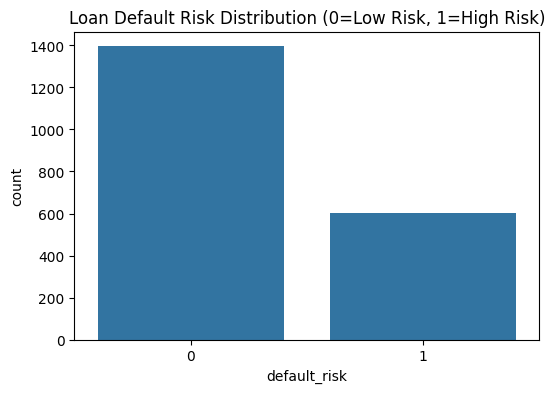

In [ ]:
# Check basic info
print("Missing values:\n", df.isnull().sum())
print("\nDefault Risk Distribution:")
print(df['default_risk'].value_counts())

# Visualize risk distribution
plt.figure(figsize=(6,4))
sns.countplot(x='default_risk', data=df)
plt.title('Loan Default Risk Distribution (0=Low Risk, 1=High Risk)')
plt.show()

In [ ]:
# Separate features and target
X = df.drop('default_risk', axis=1)
y = df['default_risk']

# Split into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (1600, 10)
Testing set size: (400, 10)


In [ ]:

# Train Logistic Regression model
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_log = log_model.predict(X_test_scaled)
y_pred_proba_log = log_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate
print("Logistic Regression Results:")
print(classification_report(y_test, y_pred_log))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba_log))

Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90       291
           1       0.73      0.72      0.73       109

    accuracy                           0.85       400
   macro avg       0.81      0.81      0.81       400
weighted avg       0.85      0.85      0.85       400

ROC-AUC Score: 0.887070840820959


In [ ]:

# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluate
print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba_rf))

Random Forest Results:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96       291
           1       0.91      0.84      0.88       109

    accuracy                           0.94       400
   macro avg       0.93      0.91      0.92       400
weighted avg       0.93      0.94      0.93       400

ROC-AUC Score: 0.9698130458085059


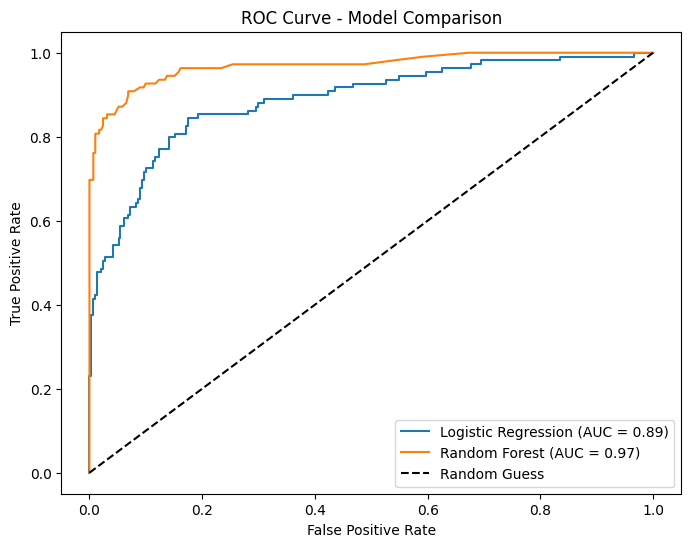

In [ ]:
# Compare both models using ROC Curve
fpr_log, tpr_log, _ = roc_curve(y_test, y_pred_proba_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_pred_proba_log):.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_pred_proba_rf):.2f})')
plt.plot([0,1], [0,1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Model Comparison')
plt.legend()
plt.show()

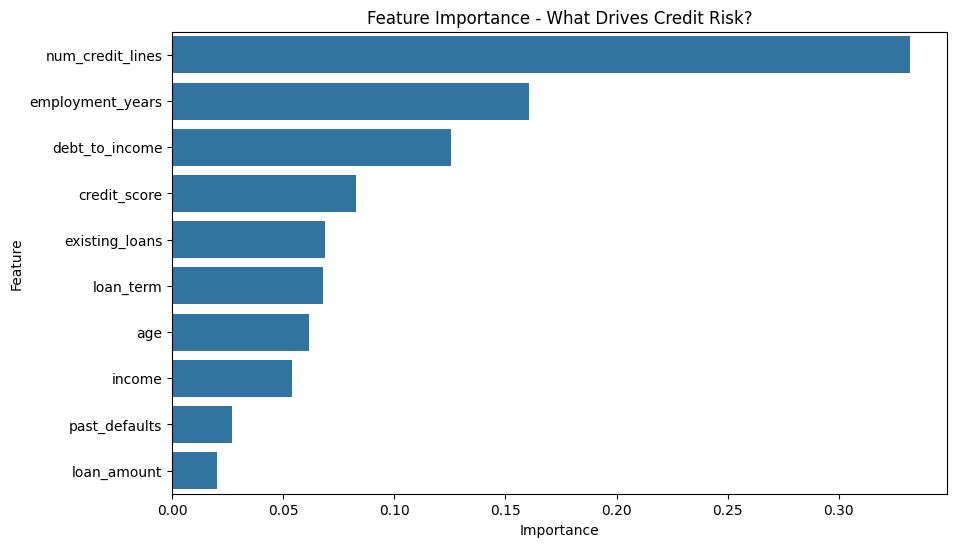

            Feature  Importance
6  num_credit_lines    0.332282
4  employment_years    0.160422
5    debt_to_income    0.125348
3      credit_score    0.082910
9    existing_loans    0.068732
8         loan_term    0.067953
0               age    0.061610
1            income    0.054048
7     past_defaults    0.026758
2       loan_amount    0.019937


In [ ]:
# Feature Importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Feature Importance - What Drives Credit Risk?')
plt.show()

print(feature_importance)

In [ ]:
print("="*50)
print("CREDIT RISK PREDICTION - FINAL SUMMARY")
print("="*50)

print(f"\nDataset Size: {df.shape[0]} borrowers, {df.shape[1]-1} features")
print(f"\nModel Comparison:")
print(f"  Logistic Regression - ROC-AUC: {roc_auc_score(y_test, y_pred_proba_log):.4f}")
print(f"  Random Forest       - ROC-AUC: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")

print(f"\nBest Model: Random Forest")
print(f"\nTop 3 Risk Factors:")
for i, row in feature_importance.head(3).iterrows():
    print(f"  {row['Feature']}: {row['Importance']:.2%}")

print("\nKey Insight: Random Forest outperformed Logistic Regression,")
print("achieving a strong ROC-AUC score of 0.97, making it suitable")
print("for deployment in real-world loan approval decision support.")

CREDIT RISK PREDICTION - FINAL SUMMARY

Dataset Size: 2000 borrowers, 10 features

Model Comparison:
  Logistic Regression - ROC-AUC: 0.8871
  Random Forest       - ROC-AUC: 0.9698

Best Model: Random Forest

Top 3 Risk Factors:
  num_credit_lines: 33.23%
  employment_years: 16.04%
  debt_to_income: 12.53%

Key Insight: Random Forest outperformed Logistic Regression,
achieving a strong ROC-AUC score of 0.97, making it suitable
for deployment in real-world loan approval decision support.
